In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from ensemble_model import EnsembleModel
import joblib

## 1. Load the Dataset

The Dataset contains one row per completed match.

Each row contains:
- the final match outcome('team0_won')
- aggreagted statistics for both teams
- statistics for each of the six players on each team
- hero an lane assignment

Statistics measured at the 5-minute snapshot.

## 2. Feature Engineering

The engineered features fall into several groups:

### Team compositions and distributions
- Carry share
- Networth standart deviation
- Richest player relative to team avarage

### Team performance
- Team kill/death ratio (KDR)

### Team-to-team differences
- Networth difference
- Damage difference
- Avarage level difference
- Carry networth difference
- KDR difference
- Gold-per-minute difference
- Objective damage difference

### Relative ratios
- Networth ratio
- Damage ratio
- Objective damage ratio

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

new_features = pd.DataFrame({
    "team0_carry_share" : (df["team0_p1_networth"]/df["team0_team_total_networth"]),
    "team1_carry_share" : (df["team1_p1_networth"]/df["team1_team_total_networth"]),
    "team0_networth_std" : df[["team0_p1_networth","team0_p2_networth","team0_p3_networth","team0_p4_networth","team0_p5_networth","team0_p6_networth"]].std(axis=1),
    "team1_networth_std" : df[["team1_p1_networth","team1_p2_networth","team1_p3_networth","team1_p4_networth","team1_p5_networth","team1_p6_networth"]].std(axis=1),
    "team0_team_kdr" : (df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1)),
    "team1_team_kdr" : (df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "team0_richest_vs_team_avg" : (df["team0_p1_networth"]/(df["team0_team_total_networth"]/6)),
    "team1_richest_vs_team_avg" : (df["team1_p1_networth"]/(df["team1_team_total_networth"]/6)),
    'networth_diff': df['team0_team_total_networth'] - df['team1_team_total_networth'],
    "damage_diff":df["team0_team_total_damage"]-df["team1_team_total_damage"],
    "level_diff":df["team0_team_avg_level"]-df["team1_team_avg_level"],
    "carry_diff":df["team0_p1_networth"] - df["team1_p1_networth"],
    "kdr_diff":(df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1))-(df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "gpm_diff" : (df["team0_team_gold_per_minute"]-df["team1_team_gold_per_minute"]),
    "objective_diff" : (df["team0_team_total_objectivedamage"]-df["team1_team_total_objectivedamage"]),
    "networth_ratio" : (df["team0_team_total_networth"]/(df["team1_team_total_networth"]+1)),
    "damage_ratio" : (df["team0_team_total_damage"]/(df["team1_team_total_damage"]+1)),
    "objective_ratio" : (df["team0_team_total_objectivedamage"]/(df["team1_team_total_objectivedamage"]+1))
})
df = pd.concat([df, new_features],axis=1)
print(df.shape)
df


(18474, 202)


,match_id,team0_won,team0_team_total_kills,team0_team_total_deaths,team0_team_total_networth,team0_team_total_damage,team0_team_total_objectivedamage,team0_team_avg_level,team0_team_gold_per_minute,team0_p1_hero,...,networth_diff,damage_diff,level_diff,carry_diff,kdr_diff,gpm_diff,objective_diff,networth_ratio,damage_ratio,objective_ratio
0,1894783,1,16,8,36572,21358,10671,8.666667,677.259184,2,...,8579,9682,1.166667,3312,1.483660,158.870353,3822,1.306423,1.829066,1.557810
1,1883785,0,1,21,21242,13837,1073,7.000000,393.370327,15,...,-26227,-9423,-2.833333,-5350,-5.204545,-485.685131,-9778,0.447483,0.594858,0.098876
2,1741000,1,9,3,33547,21566,8456,8.166667,621.240672,2,...,10368,5857,1.166667,542,1.977273,191.999979,6130,1.447239,1.372756,3.633863
3,39119945,1,5,6,41388,14982,10271,10.666667,766.444359,3,...,5566,-101,1.333333,-1616,0.142857,103.074063,8045,1.155347,0.993238,4.612034
4,30579330,0,13,6,35024,17588,2808,10.166667,648.592521,3,...,2546,-8503,0.166667,1347,1.457143,47.148143,2542,1.078358,0.674076,10.516854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18469,83270998,1,11,9,41089,26215,1726,10.500000,760.907323,25,...,-1628,-1705,-0.333333,-517,0.433333,-30.148145,-6474,0.961866,0.938899,0.210462
18470,83272008,0,4,13,35011,22184,900,9.666667,648.351780,63,...,-7641,-7589,-1.333333,-2275,-2.314286,-141.499984,-3728,0.820833,0.745080,0.194426
18471,83271597,1,15,8,42514,30291,1722,10.833333,787.296209,77,...,6190,913,1.166667,2666,1.166667,114.629617,1134,1.170379,1.031043,2.923599
18472,83271376,1,17,10,42190,29111,3063,10.833333,781.296209,1,...,4623,2025,0.833333,895,1.019139,85.611102,1072,1.123030,1.074722,1.537651


## 3. Train/Test Split

The data is split into 80% training and 20% test data

In [ ]:
X = df.drop(columns=["team0_won","match_id"])

y = df["team0_won"]

categorical_columns = []
for team in [0,1]:
    for i in range(1,7):
        categorical_columns.append(f'team{team}_p{i}_hero')
        categorical_columns.append(f'team{team}_p{i}_lane')

X = pd.get_dummies(X, columns=categorical_columns)
print(X.shape)

feature_columns = X.columns.tolist()
joblib.dump(feature_columns,"YOUR_PATH_HERE")

print(f"Saved {len(feature_columns)} feature columns.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X.columns.to_list()

(18474, 679)
Saved 679 feature columns.


['team0_team_total_kills',
 'team0_team_total_deaths',
 'team0_team_total_networth',
 'team0_team_total_damage',
 'team0_team_total_objectivedamage',
 'team0_team_avg_level',
 'team0_team_gold_per_minute',
 'team0_p1_kills',
 'team0_p1_deaths',
 'team0_p1_assists',
 'team0_p1_networth',
 'team0_p1_damage',
 'team0_p1_creeps',
 'team0_p1_level',
 'team0_p1_objective_damage',
 'team0_p1_denies',
 'team0_p1_gold_per_minute',
 'team0_p1_player_healing',
 'team0_p1_self_healing',
 'team0_p2_kills',
 'team0_p2_deaths',
 'team0_p2_assists',
 'team0_p2_networth',
 'team0_p2_damage',
 'team0_p2_creeps',
 'team0_p2_level',
 'team0_p2_objective_damage',
 'team0_p2_denies',
 'team0_p2_gold_per_minute',
 'team0_p2_player_healing',
 'team0_p2_self_healing',
 'team0_p3_kills',
 'team0_p3_deaths',
 'team0_p3_assists',
 'team0_p3_networth',
 'team0_p3_damage',
 'team0_p3_creeps',
 'team0_p3_level',
 'team0_p3_objective_damage',
 'team0_p3_denies',
 'team0_p3_gold_per_minute',
 'team0_p3_player_healing'

## 4. Baseline Performance

As an initial benchmark, an XGB classifier and RandomForest classifier are trained with a relatively simple configurations.

The baseline models achive roughly 66% test accuracy

In [ ]:
model_xgb = XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,random_state=42)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy_xgb}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.6611637347767253

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.66      0.66      1834
           1       0.66      0.67      0.66      1861

    accuracy                           0.66      3695
   macro avg       0.66      0.66      0.66      3695
weighted avg       0.66      0.66      0.66      3695



In [5]:
importance = pd.DataFrame({"feature": X.columns, "importance": model_xgb.feature_importances_})

importance = importance.sort_values(by="importance",ascending=False)

importance

,feature,importance
166,networth_diff,0.066994
173,networth_ratio,0.031913
168,level_diff,0.019944
172,objective_diff,0.012542
174,damage_ratio,0.009866
...,...,...
602,team1_p5_hero_10,0.000000
601,team1_p5_hero_8,0.000000
648,team1_p6_hero_14,0.000000
37,team0_p3_level,0.000000


In [ ]:
model_rf = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42)

model_rf.fit(X_train, y_train)

rf_predictions = model_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy}")

print("\nRandom Forest Report:")

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.6519621109607577

Random Forest Report:

              precision    recall  f1-score   support

           0       0.65      0.65      0.65      1834
           1       0.65      0.65      0.65      1861

    accuracy                           0.65      3695
   macro avg       0.65      0.65      0.65      3695
weighted avg       0.65      0.65      0.65      3695



In [7]:
rf_importance = pd.DataFrame({"feature": X.columns,"importance": model_rf.feature_importances_})

rf_importance = rf_importance.sort_values(by="importance",ascending=False)

print(rf_importance.head(20))

                              feature  importance
173                    networth_ratio    0.039422
166                     networth_diff    0.034479
168                        level_diff    0.028187
171                          gpm_diff    0.024856
172                    objective_diff    0.017941
163                    team1_team_kdr    0.017104
170                          kdr_diff    0.016528
175                   objective_ratio    0.016194
162                    team0_team_kdr    0.016147
174                      damage_ratio    0.015863
167                       damage_diff    0.014400
169                        carry_diff    0.013493
2           team0_team_total_networth    0.012731
85         team1_team_gold_per_minute    0.011339
6          team0_team_gold_per_minute    0.011294
83   team1_team_total_objectivedamage    0.010760
4    team0_team_total_objectivedamage    0.010502
58                  team0_p5_networth    0.009683
5                team0_team_avg_level    0.009126


## 5. Tuned XGBoost

The next experiment uses a more regularized XGBoost configuration.

In [ ]:
model_xgb = XGBClassifier(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.03,

    subsample=0.7,

    colsample_bytree=0.7,

    min_child_weight=7,

    gamma=2,

    reg_alpha=2,

    reg_lambda=10,

    random_state=42,
)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.6635994587280108

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.65      0.66      1834
           1       0.66      0.68      0.67      1861

    accuracy                           0.66      3695
   macro avg       0.66      0.66      0.66      3695
weighted avg       0.66      0.66      0.66      3695



The tuned model achives ~66.4% test accuracy and ~73.7% train accuracy

In [ ]:
train_acc = model_xgb.score(X_train, y_train)

test_acc = model_xgb.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.736856350226673
0.6635994587280108


### 6. ROC-AUC

Because the final application outputs a win probability rather than only a binary prediction, accuracy alone is not sufficient.

ROC-AUC measures how well the model ranks winning teams above losing teams across different probability thresholds.

For the tuned XGBoost model, the test ROC-AUC is approximately 0.723.

In [ ]:
from sklearn.metrics import roc_auc_score

probs=model_xgb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, probs))


0.7233737094478467


## 7. CatBoost

CatBoost is evaluated as a second gradient-boosting model.

It recieves approximately 67% test accuracy and 0.728 ROC-AUC score.

In [ ]:
model_cat = CatBoostClassifier(

    iterations=1500,

    depth=4,

    learning_rate=0.02,

    l2_leaf_reg=15,

    min_data_in_leaf=30,

    random_strength=5,

    bagging_temperature=2,

    verbose=100,

    random_seed=42
)

model_cat.fit(X_train, y_train)

probs = model_cat.predict_proba(X_test)[:,1]

predictions = model_cat.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for CAT: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

pred=(probs>0.5)

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs))

0:	learn: 0.6909999	total: 151ms	remaining: 3m 46s
100:	learn: 0.6298767	total: 970ms	remaining: 13.4s
200:	learn: 0.6208963	total: 1.87s	remaining: 12.1s
300:	learn: 0.6170193	total: 2.7s	remaining: 10.8s
400:	learn: 0.6141396	total: 3.68s	remaining: 10.1s
500:	learn: 0.6109969	total: 4.49s	remaining: 8.95s
600:	learn: 0.6057281	total: 5.24s	remaining: 7.84s
700:	learn: 0.5984169	total: 6.04s	remaining: 6.89s
800:	learn: 0.5910619	total: 6.87s	remaining: 6s
900:	learn: 0.5843683	total: 7.72s	remaining: 5.13s
1000:	learn: 0.5779348	total: 8.75s	remaining: 4.36s
1100:	learn: 0.5719567	total: 9.59s	remaining: 3.47s
1200:	learn: 0.5659584	total: 10.4s	remaining: 2.6s
1300:	learn: 0.5599727	total: 11.2s	remaining: 1.71s
1400:	learn: 0.5543588	total: 12.2s	remaining: 863ms
1499:	learn: 0.5489463	total: 13.2s	remaining: 0us
Accuracy for CAT: 0.6673883626522328

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.66      0.66      1834

In [ ]:
train_acc = model_cat.score(X_train, y_train)

test_acc = model_cat.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.7219026997767102
0.6673883626522328


## 8. Ensemble Model

The final predictor combines the XGBoost and CatBoost models using simple soft-voting ensemble. For each match, both models produce class probabilities, which are then avaraged using arithmetic mean.

On the test set ensemble achieves approxiamtely 66.5% accuracy and 0.727 ROC-AUC score.

In [ ]:
ensemble = EnsembleModel(model_xgb, model_cat)
joblib.dump(ensemble, 'YOUR_PATH_HERE')

pred = ensemble.predict(X_test)
probs = ensemble.predict_proba(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs[:, 1]))

0.6652232746955345
0.7267375392388211


## 9. Calibration Curve

A calibration curve compares predicted probabilities with the observed frequency of the positive class.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_xgb,method='isotonic',cv=5)

calibrated.fit( X_train,y_train)

probs = calibrated.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, probs))

0.7250443441894316


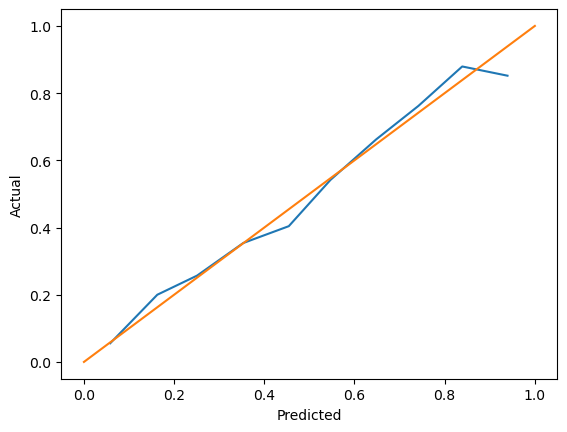

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true)

plt.plot([0,1], [0,1])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 10. Model Explainability with SHAP

SHAP is used to investigate which features influence the XGBoost predictions.

Two visualizations are produced:

1. A SHAP summary plot showing the overall importance and direction of feature contributions.
2. A bar plot showing aggregated feature importance.

This provides an interpretable view of which aspects of the game influance the model prediction the most.

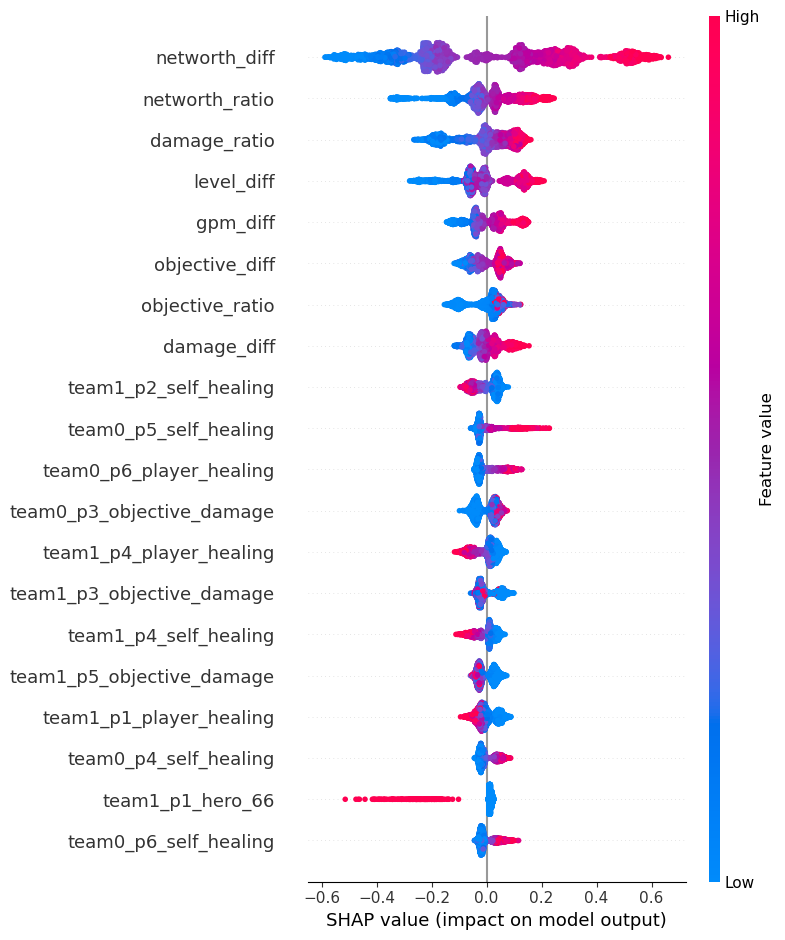

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = (explainer.shap_values( X_test))

shap.summary_plot(shap_values, X_test)

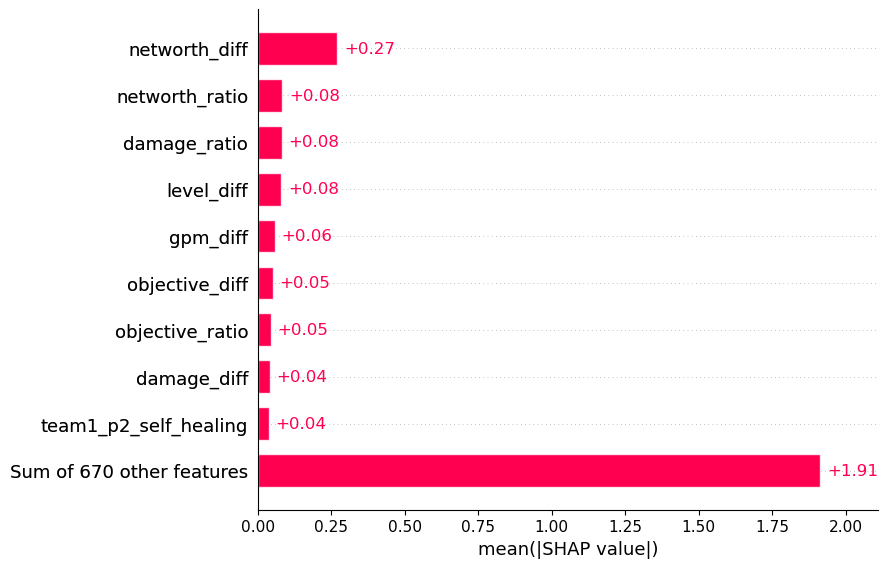

In [ ]:
shap.plots.bar(shap.Explanation(values=shap_values, data=X_test.values, feature_names=X_test.columns))